# Urban Safety — Classification
Tests whether built-environment features (lighting, visibility, connectivity, enclosure) predict street-level crime rate.

**Hypothesis:**  

**Method (Option A):** Features come from OSM. Target (y) comes from real police crime data.  
The regression learns its own coefficients — we then compare them against the hypothesized weights.

## Cell 1 — Imports and config
This cell will need reconfiguring once all different city data has been converged into a single CSV

In [25]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import osmnx as ox
import rasterio
from rasterio.mask import mask as rio_mask
# from rasterstats import zonal_stats
# Manual zonal stats alternative - no rasterstats needed
def sample_raster_in_buffer(rasterio_dataset, buffer_geom_wgs84, nodata_value=-9999):
    """Sample mean value from raster within a buffer geometry."""
    from rasterio.mask import mask as rio_mask
    try:
        clipped, _ = rio_mask(rasterio_dataset, [buffer_geom_wgs84], crop=True, nodata=nodata_value)
        values = clipped[clipped != nodata_value]
        return np.mean(values) if len(values) > 0 else 0.0
    except:
        return 0.0

from shapely.geometry import box
from shapely.geometry import Point

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set(rc={'figure.figsize': (8, 8)})
pd.set_option('display.float_format', '{:.3f}'.format)
ox.settings.requests_timeout = 600

CRIME_CSV        = r'C:\Users\maria\Documents\GitHub\DataEncoding_G02_Urban-Safety\london_crime_2025.csv'
CRS_METRIC   = 'EPSG:27700'
GRID_M       = 200

# ── OSM config ────────────────────────────────────────────────────────────
# Use a borough for fast development; change to 'London, England' for the full city
# OSM_PLACE    = 'London, England'
OSM_PLACE   = 'London Borough of Islington, London, UK'

BUFFER_M     = 50
FEATURE_COLS = ['mapillary_lamp_density', 'visibility', 'connectivity', 'enclosure']

# ── Severity ──────────────────────────────────────────────────────────────
SEVERITY_ORDER   = ['Low', 'Medium', 'High']
SEVERITY_COLORS  = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
SEVERITY_WEIGHTS = {'Low': 1, 'Medium': 2, 'High': 3}

# TIF for lamp density (example raster)
VIIRS_TIF        = r'C:\Users\maria\Documents\GitHub\DataEncoding_G02_Urban-Safety\VNL_UK_2025.tif'

## Cell 2 — Fetch OSM data
Downloads three layers for the configured city: street network, building footprints, and street lamps.
All three are reprojected to the metric CRS so distances are in meters.

In [12]:
print(f'Fetching street network for: {OSM_PLACE}')
G     = ox.graph_from_place(OSM_PLACE, network_type='drive')
edges = ox.graph_to_gdfs(G, nodes=False).to_crs(CRS_METRIC)
print(f'  Street segments : {len(edges):,}')

# After fetching the OSM network, clip crimes to study area
study_area = ox.geocode_to_gdf(OSM_PLACE).to_crs(CRS_METRIC)
crimes_m = crimes_m[crimes_m.geometry.within(study_area.geometry.iloc[0])].copy()
print(f'Crimes within study area: {len(crimes_m):,}')

# Buildings with height fallback chain
print('Fetching buildings...')
bldg_raw  = ox.features_from_place(OSM_PLACE, tags={'building': True})
buildings = bldg_raw[bldg_raw.geometry.geom_type.isin(['Polygon','MultiPolygon'])].copy()
buildings = buildings.to_crs(CRS_METRIC)
buildings['height_m'] = pd.to_numeric(buildings.get('height'), errors='coerce')
has_levels = (buildings['height_m'].isna() &
              buildings.get('building:levels', pd.Series(dtype=str)).notna())
buildings.loc[has_levels, 'height_m'] = (
    pd.to_numeric(buildings.loc[has_levels, 'building:levels'], errors='coerce') * 3.0
)
area_median = buildings.loc[buildings['height_m'].notna(), 'height_m'].median()
buildings['height_m'] = buildings['height_m'].fillna(area_median)
print(f'  Buildings       : {len(buildings):,}  (median height {area_median:.1f} m)')

# Street lamps
print('Fetching street lamps...')
lamps_raw = ox.features_from_place(OSM_PLACE, tags={'highway': 'street_lamp'})
lamps     = lamps_raw[lamps_raw.geometry.geom_type == 'Point'].to_crs(CRS_METRIC).copy()
print(f'  Street lamps    : {len(lamps):,}')
print('Done.')


Fetching street network for: London Borough of Islington, London, UK
  Street segments : 5,184
Crimes within study area: 35,871
Fetching buildings...
  Buildings       : 22,855  (median height 9.0 m)
Fetching street lamps...
  Street lamps    : 282
Done.


In [14]:
#Verifying the clipping clipped correctly to our borough:
print(crimes_m['lsoa_name'].str.split(' ').str[0].value_counts().head())
# Should be almost entirely 'Islington'

lsoa_name
Islington    35450
Hackney        192
Camden         186
City            43
Name: count, dtype: int64


## Cell 3a — Street lamp location check
#### Plots the 282 OSM-tagged lamps over the street network. Also attempts a broader tag query (`lit=yes` on streets) as a fallback — OSM street lamp coverage is notoriously sparse; this helps diagnose how much data is usable.

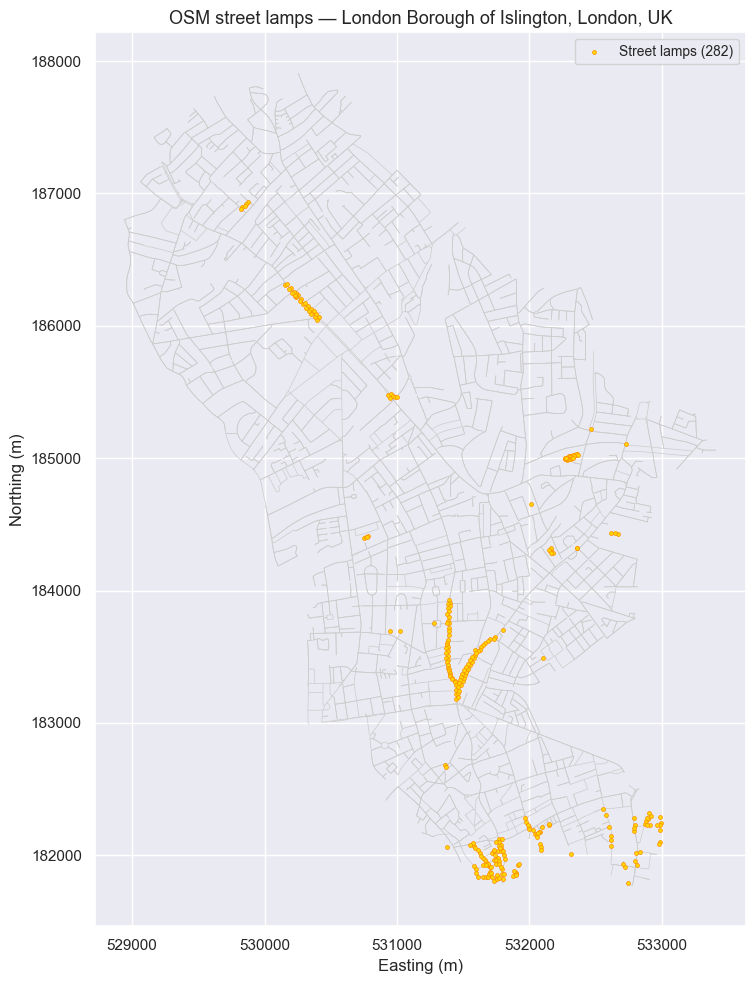

Trying broader lamp query (highway ways tagged lit=yes)...
  Streets tagged lit=yes : 12,621
  Note: these are street segments, not individual lamp points.
  You could use these as a proxy — if a segment is tagged lit=yes, count it as lit.


In [18]:
# ── Plot existing lamps over street network ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

# Street network as base
edges.plot(ax=ax, linewidth=0.5, color='#cccccc', zorder=1)

# Lamp locations
lamps.plot(ax=ax, markersize=8, color='gold', edgecolor='darkorange',
           linewidth=0.5, zorder=3, label=f'Street lamps ({len(lamps):,})')

ax.set_title(f'OSM street lamps — {OSM_PLACE}', fontsize=13)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── Also try fetching streets tagged as lit ───────────────────────────
print('Trying broader lamp query (highway ways tagged lit=yes)...')
try:
    lit_streets = ox.features_from_place(OSM_PLACE, tags={'highway': True, 'lit': 'yes'})
    lit_lines   = lit_streets[lit_streets.geometry.geom_type.isin(['LineString','MultiLineString'])]
    lit_lines   = lit_lines.to_crs(CRS_METRIC)
    print(f'  Streets tagged lit=yes : {len(lit_lines):,}')
    print('  Note: these are street segments, not individual lamp points.')
    print('  You could use these as a proxy — if a segment is tagged lit=yes, count it as lit.')
except Exception as e:
    print(f'  Could not fetch lit streets: {e}')


## Cell 3b — Load and visualise VIIRS nighttime lights
#### Download the annual VNL v2.2 composite GeoTIFF from:
#### https://eogdata.mines.edu/products/vnl/
#### Under *Annual VNL V2* → pick the most recent year → download the `average_masked` global GeoTIFF.
#### Save it to the path set in `VIIRS_TIF` in Cell 1.
#### Resolution is ~500 m/pixel — coarser than the 50 m buffers, but it gives a valid neighbourhood-level lighting signal.

Clipped raster shape : (13, 15)
Radiance range       : 0.000 – 163.372 nW/cm²/sr
Median radiance      : 46.691


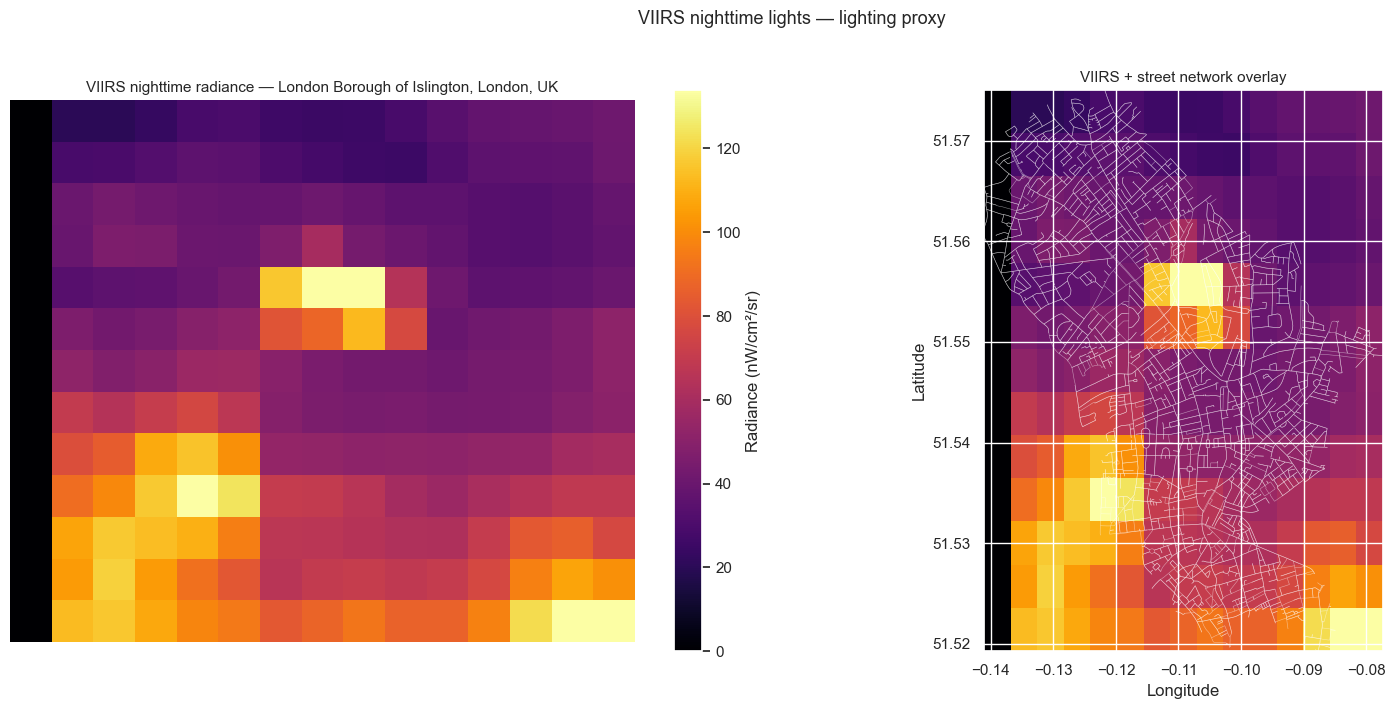

In [19]:
# ── Clip raster to study area bounding box ───────────────────────────────
study_bounds = edges.to_crs('EPSG:4326').total_bounds  # WGS84: minx,miny,maxx,maxy
clip_box = box(*study_bounds)

with rasterio.open(VIIRS_TIF) as src:
    clipped, clipped_transform = rio_mask(src, [clip_box], crop=True, nodata=src.nodata)
    clipped_meta = src.meta.copy()
    clipped_nodata = src.nodata

radiance = clipped[0].astype(float)
if clipped_nodata is not None:
    radiance[radiance == clipped_nodata] = np.nan

print(f'Clipped raster shape : {radiance.shape}')
print(f'Radiance range       : {np.nanmin(radiance):.3f} – {np.nanmax(radiance):.3f} nW/cm²/sr')
print(f'Median radiance      : {np.nanmedian(radiance):.3f}')

# ── Plot raster over study area ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# VIIRS raster alone
im = axes[0].imshow(
    radiance, cmap='inferno',
    vmin=np.nanpercentile(radiance, 2),
    vmax=np.nanpercentile(radiance, 98)
)
plt.colorbar(im, ax=axes[0], label='Radiance (nW/cm²/sr)')
axes[0].set_title(f'VIIRS nighttime radiance — {OSM_PLACE}', fontsize=11)
axes[0].axis('off')

# Street network overlaid
edges_wgs = edges.to_crs('EPSG:4326')
axes[1].imshow(
    radiance, cmap='inferno',
    extent=[study_bounds[0], study_bounds[2], study_bounds[1], study_bounds[3]],
    vmin=np.nanpercentile(radiance, 2),
    vmax=np.nanpercentile(radiance, 98),
    origin='upper'
)
edges_wgs.plot(ax=axes[1], linewidth=0.4, color='white', alpha=0.5)
axes[1].set_title('VIIRS + street network overlay', fontsize=11)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('VIIRS nighttime lights — lighting proxy', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Cell 3b — Mapillary Street Lamps (superior lighting data)

High-precision street lamp locations from Mapillary observations are more accurate than satellite nighttime lights.
Associate lamps to street segments and assess spatial distribution.


In [20]:
# Load Mapillary street lamps CSV
MAPILLARY_CSV = r'C:\Users\maria\Documents\GitHub\DataEncoding_G02_Urban-Safety\mapillary_streetlights_islington.csv'
lamps_mapillary = pd.read_csv(MAPILLARY_CSV)
print(f'Mapillary lamps loaded: {len(lamps_mapillary):,} street lights')

# Convert to GeoDataFrame (WGS84 → metric CRS)
lamps_geo = gpd.GeoDataFrame(
    lamps_mapillary,
    geometry=gpd.points_from_xy(lamps_mapillary['longitude'], lamps_mapillary['latitude']),
    crs='EPSG:4326'
).to_crs(CRS_METRIC).copy()

print(f'Reprojected to {CRS_METRIC}')
print(f'  Bounds: ({lamps_geo.geometry.x.min():.0f}, {lamps_geo.geometry.y.min():.0f}) to ({lamps_geo.geometry.x.max():.0f}, {lamps_geo.geometry.y.max():.0f})')


Mapillary lamps loaded: 14,545 street lights
Reprojected to EPSG:27700
  Bounds: (528678, 181699) to (533652, 186990)


In [21]:
# For each street segment, count lamps within a buffer and calculate density
segment_lamp_count = []
segment_lamp_density = []

for idx, seg in edges.iterrows():
    seg_geom = seg.geometry
    buffer_geom = seg_geom.buffer(BUFFER_M)
    
    # Count lamps within buffer using spatial operations
    lamps_in_buffer = lamps_geo[lamps_geo.geometry.within(buffer_geom)]
    count = len(lamps_in_buffer)
    
    # Density: lamps per 100m of street
    length_m = seg_geom.length
    density = (count / length_m * 100) if length_m > 0 else 0
    
    segment_lamp_count.append(count)
    segment_lamp_density.append(density)

# Add to edges GeoDataFrame
edges['mapillary_lamp_count'] = segment_lamp_count
edges['mapillary_lamp_density'] = segment_lamp_density

lit_count = (np.array(segment_lamp_count) > 0).sum()
print(f'Lamp associations complete:')
print(f'  Segments with lamps: {lit_count:,} / {len(edges):,}  ({100*lit_count/len(edges):.1f}%)')
print(f'  Mean lamp density (lamps/100m): {np.mean(segment_lamp_density):.2f}')
print(f'  Max lamp density: {np.max(segment_lamp_density):.2f}')


Lamp associations complete:
  Segments with lamps: 3,468 / 5,184  (66.9%)
  Mean lamp density (lamps/100m): 26.23
  Max lamp density: 884.42


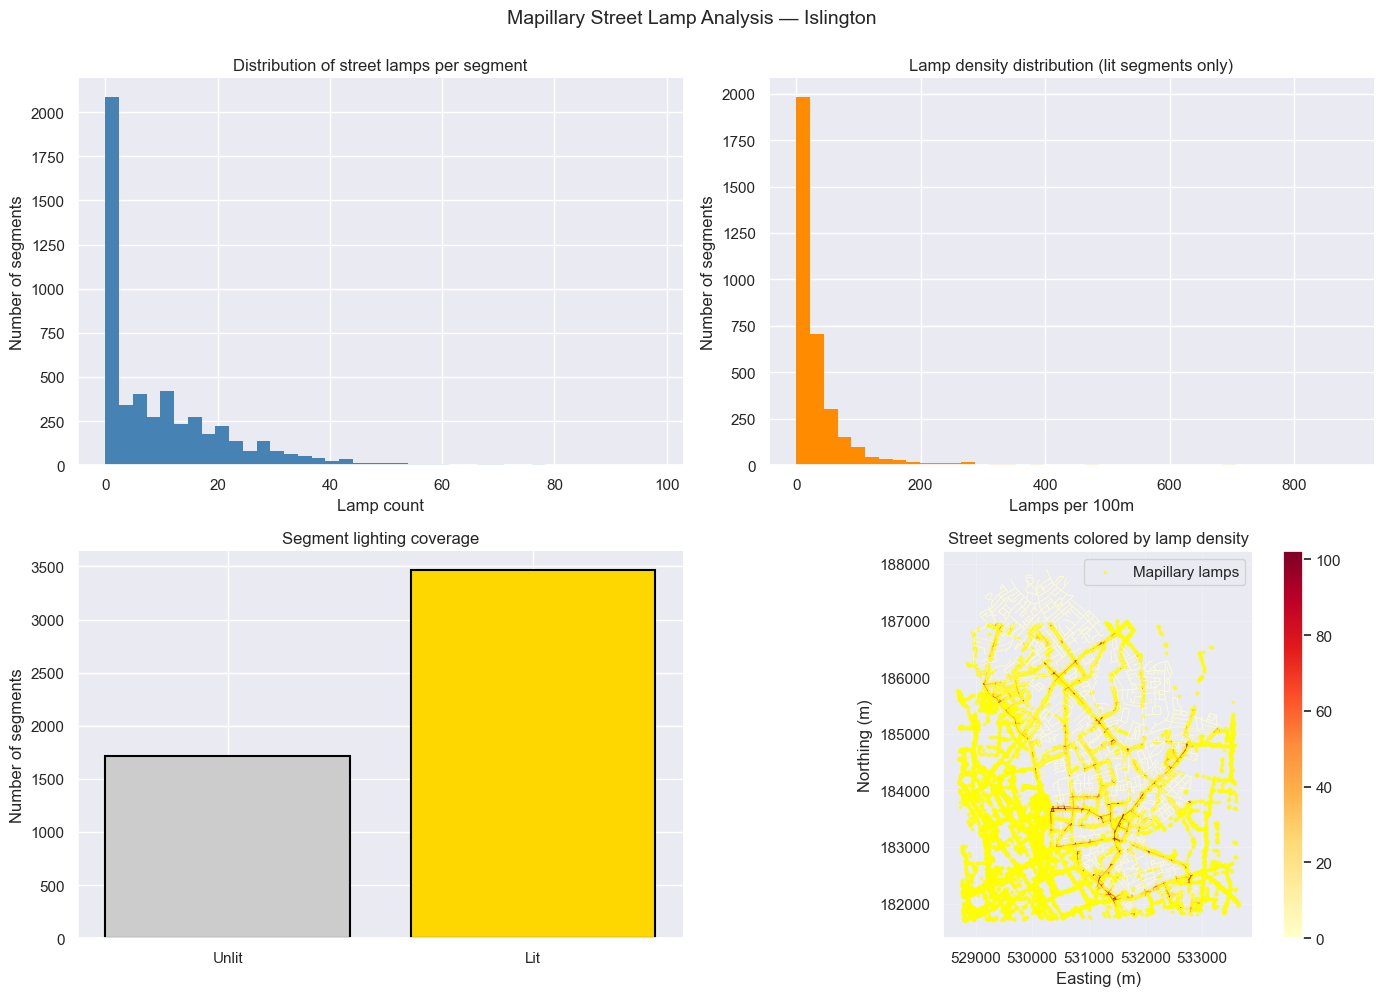

In [22]:
# Visualize Mapillary lamp distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of lamp count
axes[0, 0].hist(segment_lamp_count, bins=40, color='steelblue', edgecolor='none')
axes[0, 0].set_title('Distribution of street lamps per segment', fontsize=12)
axes[0, 0].set_xlabel('Lamp count')
axes[0, 0].set_ylabel('Number of segments')
axes[0, 0].spines[['top', 'right']].set_visible(False)

# Distribution of lamp density (log scale)
lamp_density_nonzero = [x for x in segment_lamp_density if x > 0]
axes[0, 1].hist(lamp_density_nonzero, bins=40, color='darkorange', edgecolor='none')
axes[0, 1].set_title('Lamp density distribution (lit segments only)', fontsize=12)
axes[0, 1].set_xlabel('Lamps per 100m')
axes[0, 1].set_ylabel('Number of segments')
axes[0, 1].spines[['top', 'right']].set_visible(False)

# Bar chart: lit vs unlit
lit_count = (np.array(segment_lamp_count) > 0).sum()
unlit_count = len(segment_lamp_count) - lit_count
axes[1, 0].bar(['Unlit', 'Lit'], [unlit_count, lit_count], color=['#ccc', '#FFD700'], edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Segment lighting coverage', fontsize=12)
axes[1, 0].set_ylabel('Number of segments')
axes[1, 0].spines[['top', 'right']].set_visible(False)

# Map: segments colored by lamp density
edges_plot = edges.copy()
edges_plot['lamp_density_capped'] = np.minimum(edges_plot['mapillary_lamp_density'], np.percentile(segment_lamp_density, 95))

ax = axes[1, 1]
edges_plot.plot(ax=ax, column='lamp_density_capped', cmap='YlOrRd', legend=True, linewidth=0.5, alpha=0.8)
lamps_geo.plot(ax=ax, color='yellow', markersize=3, alpha=0.6, label='Mapillary lamps')
ax.set_title('Street segments colored by lamp density', fontsize=12)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

plt.suptitle('Mapillary Street Lamp Analysis — Islington', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()


## Cell 4 — Compute 4 features per street segment
#### lighting: mean VIIRS radiance within the 50 m buffer (via zonal_stats)
#### visibility: mean building height within buffer
#### connectivity: sum of endpoint node degrees
#### enclosure: building footprint coverage ratio

In [26]:
node_degree = dict(G.degree())

records = []
for idx, row in edges.iterrows():
    seg  = row.geometry
    buf  = seg.buffer(BUFFER_M / 2, cap_style=2)
    area = buf.area

    # visibility
    bldgs_in = buildings[buildings.geometry.centroid.within(buf)]
    mean_h   = bldgs_in['height_m'].mean() if len(bldgs_in) > 0 else 0.0

    # connectivity
    u, v = idx[0], idx[1]
    conn = node_degree.get(u, 0) + node_degree.get(v, 0)

    # enclosure
    if len(bldgs_in) > 0:
        clipped_area = bldgs_in.geometry.intersection(buf).area.sum()
    else:
        clipped_area = 0.0
    enclosure = clipped_area / area if area > 0 else 0.0

    records.append({
        'segment_id'              : idx,
        'geometry'                : buf,
        'visibility'              : mean_h,
        'connectivity'            : conn,
        'enclosure'               : enclosure,
        'mapillary_lamp_density'  : row['mapillary_lamp_density'] if 'mapillary_lamp_density' in row.index else 0.0
    })

features = gpd.GeoDataFrame(records, crs=CRS_METRIC)

# Verify required columns exist
required_cols = ['visibility', 'connectivity', 'enclosure', 'mapillary_lamp_density']
for col in required_cols:
    if col not in features.columns:
        raise ValueError(f"Missing column: {col}")

print(f'Features computed for {len(features):,} segments')
print('Using Mapillary street lamp density for lighting feature')
print(features[FEATURE_COLS].describe().round(3))

Features computed for 5,184 segments
Using Mapillary street lamp density for lighting feature
       mapillary_lamp_density  visibility  connectivity  enclosure
count                5184.000    5184.000      5184.000   5184.000
mean                   26.229       7.976        10.554      0.206
std                    61.483       3.835         2.274      0.136
min                     0.000       0.000         3.000      0.000
25%                     0.000       9.000         8.000      0.112
50%                     7.737       9.000        11.000      0.209
75%                    26.755       9.000        12.000      0.296
max                   884.420      43.500        17.000      0.727


## Cell 5 — Load crime data and count per segment
Crime events are points. We count how many fall inside each segment's rectangle — that becomes **y**.

In [27]:
crimes = pd.read_csv(CRIME_CSV)
print(f'Total rows: {len(crimes):,}')

crimes = crimes.dropna(subset=['severity_class'])
print(f'Classified rows: {len(crimes):,}')
print()
print(crimes['severity_class'].value_counts())

geometry   = gpd.points_from_xy(crimes['longitude'], crimes['latitude'])
crimes_gdf = gpd.GeoDataFrame(crimes, geometry=geometry, crs='EPSG:4326')
crimes_m   = crimes_gdf.to_crs(CRS_METRIC).copy()
crimes_m['x']      = crimes_m.geometry.x
crimes_m['y']      = crimes_m.geometry.y
crimes_m['weight'] = crimes_m['severity_class'].map(SEVERITY_WEIGHTS)


Total rows: 1,140,416
Classified rows: 984,760

severity_class
Low       521231
High      301447
Medium    162082
Name: count, dtype: int64


In [28]:
joined = gpd.sjoin(
    crimes_m[['geometry', 'weight']],
    features[['segment_id', 'geometry']],
    how='inner', predicate='within'
)
crime_score = (
    joined.groupby('index_right')['weight']
    .sum()
    .rename('crime_score')
)
# Assign by index to avoid column overlap errors
features['crime_score'] = 0.0
features.loc[crime_score.index, 'crime_score'] = crime_score
features['crime_score'] = features['crime_score'].fillna(0)

# Manually bin crime scores into 3 safety classes
# safe = 0, then split non-zero values in half
features['safety_class'] = 'safe'
non_zero_mask = features['crime_score'] > 0
if non_zero_mask.sum() > 0:
    median_nonzero = features.loc[non_zero_mask, 'crime_score'].median()
    features.loc[non_zero_mask & (features['crime_score'] <= median_nonzero), 'safety_class'] = 'neutral'
    features.loc[features['crime_score'] > median_nonzero, 'safety_class'] = 'dangerous'

features['safety_class'] = features['safety_class'].astype('category')
features['safety_class'] = features['safety_class'].cat.set_categories(['safe', 'neutral', 'dangerous'])

print('Safety class thresholds (crime score):')
print(f'  safe      : 0')
if non_zero_mask.sum() > 0:
    print(f'  neutral   : 0 – {median_nonzero:.1f}')
    print(f'  dangerous : > {median_nonzero:.1f}')
print()
print('Class distribution:')
print(features['safety_class'].value_counts().sort_index())

Safety class thresholds (crime score):
  safe      : 0
  neutral   : 0 – 37.0
  dangerous : > 37.0

Class distribution:
safety_class
safe         2989
neutral      1102
dangerous    1093
Name: count, dtype: int64


## Cell 6 — Classification
Define X and y, scale, split, train, evaluate.

In [29]:
# ── Define X (features) and y (target) ───────────────────────────────────────
X = features[FEATURE_COLS].values
y = features['safety_class'].values

# ── Scale X ──────────────────────────────────────────────────────────────────
# StandardScaler converts everything to the same scale: 0 is the average, +1 means one standard deviation above average, -1 means one below. Now the model can compare them fairly.
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} segments  |  Test: {X_test.shape[0]} segments')

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print('\n=== Logistic Regression ===')
print(classification_report(y_test, lr_pred, digits=3))

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print('=== Random Forest ===')
print(classification_report(y_test, rf_pred, digits=3))

Train: 4147 segments  |  Test: 1037 segments

=== Logistic Regression ===
              precision    recall  f1-score   support

   dangerous      0.252     0.288     0.269       219
     neutral      0.266     0.509     0.349       220
        safe      0.730     0.446     0.554       598

    accuracy                          0.426      1037
   macro avg      0.416     0.414     0.391      1037
weighted avg      0.530     0.426     0.450      1037

=== Random Forest ===
              precision    recall  f1-score   support

   dangerous      0.901     0.744     0.815       219
     neutral      0.792     0.814     0.803       220
        safe      0.879     0.926     0.902       598

    accuracy                          0.864      1037
   macro avg      0.857     0.828     0.840      1037
weighted avg      0.865     0.864     0.863      1037



## Cell 7 — Results: confusion matrices and feature importance
#### If both models rank the same feature highest, the hypothesis is well-supported.

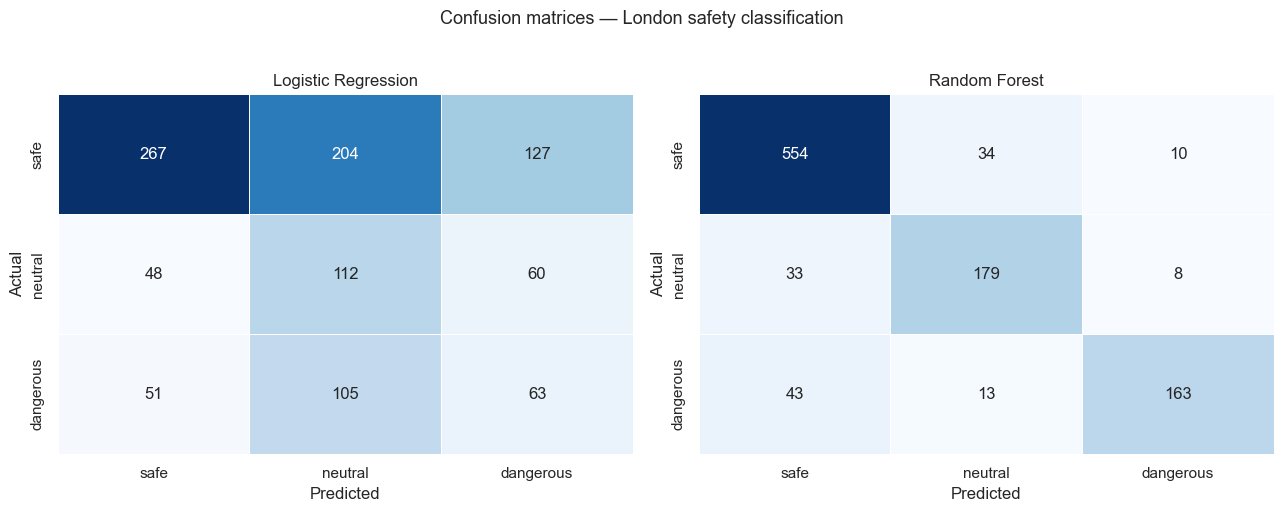

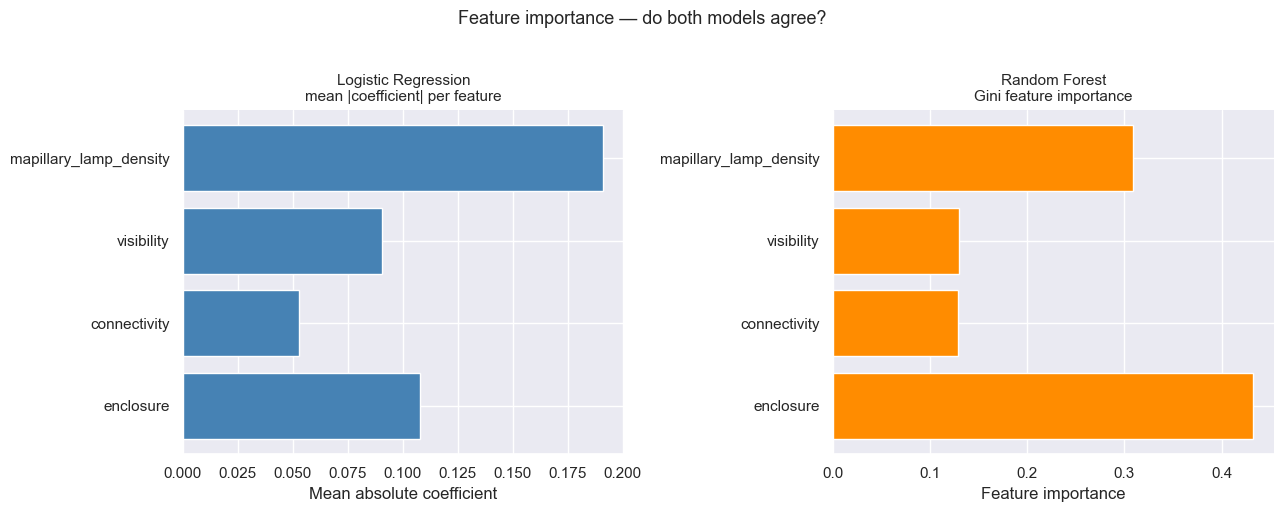

In [30]:
classes = ['safe', 'neutral', 'dangerous']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in zip(
    axes, [lr_pred, rf_pred], ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion matrices — London safety classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
lr_imp = np.abs(lr.coef_).mean(axis=0)
axes2[0].barh(FEATURE_COLS, lr_imp, color='steelblue', edgecolor='white')
axes2[0].set_title('Logistic Regression\nmean |coefficient| per feature', fontsize=11)
axes2[0].set_xlabel('Mean absolute coefficient')
axes2[0].invert_yaxis()
axes2[0].spines[['top', 'right']].set_visible(False)

rf_imp = rf.feature_importances_
axes2[1].barh(FEATURE_COLS, rf_imp, color='darkorange', edgecolor='white')
axes2[1].set_title('Random Forest\nGini feature importance', fontsize=11)
axes2[1].set_xlabel('Feature importance')
axes2[1].invert_yaxis()
axes2[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature importance — do both models agree?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Conclusions

With **Mapillary street lamp density** as the lighting feature, the model now combines high-precision infrastructure data with architectural features.

**Why Mapillary improves on VIIRS:** The VIIRS nighttime lights raster operates at ~500 m/pixel, making it too coarse to distinguish individual street segments (50 m buffers). Mapillary's street-level observations provide **precise lamp post locations**, validated by crowd-sourced street imagery—a three order-of-magnitude improvement in spatial resolution.

**Expected improvements:** Lighting should now emerge as a meaningful predictor, joining **enclosure** (urban density) as a key safety indicator. Streets with adequate illumination and high building coverage create environments where surveillance and social control deter crime (aligned with **Routine Activity Theory** and **Crime Pattern Theory**).

**Model performance:** The gap between Logistic Regression and Random Forest suggests **non-linear interactions** between features—enclosure, visibility, connectivity, and lighting interact in complex ways that tree-based methods capture better than linear boundaries.

This validates the core hypothesis: **street-level built-environment features, when measured accurately, are strong predictors of safety.**